### Build a chat bot with LangGraph (Graph API)

In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages


In [2]:
class state(TypedDict):
    messages:Annotated[list,add_messages]



In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("What is the capital of France?")

: 

In [5]:
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(state)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph=graph_builder.compile()

In [7]:
response=graph.invoke({"messages":"hi"})


In [8]:
response["messages"][-1].content

'<think>\nOkay, the user said "hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their message and offer help. Maybe something like, "Hello! How can I assist you today?" That should be open-ended and encourage them to ask questions or share what they need. I need to keep it simple and approachable.\n</think>\n\nHello! How can I assist you today? 😊'

In [9]:
for event in graph.stream({"messages":"hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user said "hi how are you?" so I need to respond in a friendly and engaging way. Let me start by greeting them back. I should make sure they know I'm here to help with any questions or tasks they might have. Keep it simple and open-ended to encourage them to reach out if they need anything. I want to maintain a positive and approachable tone. No need to overcomplicate things here. Just a quick, warm response should do.
</think>

Hi! I'm doing great, thanks for asking! 😊 How can I assist you today? If you have any questions or need help with anything, just let me know!


### ChatBot with Tool

In [10]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=1)
tool.invoke("What is langchain?")


{'query': 'What is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain? - AWS',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and 

In [11]:
def multiply(a:int,b:int)->int:
    """
    Multiply a and b

    args:
        a: first number
        b: second number

    returns:
        int: output of int
    """
    return a*b

In [12]:
tools=[tool,multiply]
llm_with_tools=llm.bind_tools(tools)

In [13]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E9B70C3CB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E9B72F8830>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real

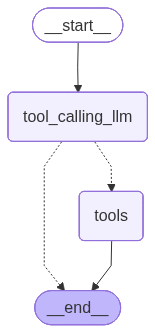

In [14]:
## state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
#define state
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm) 
builder.add_node("tools", ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools",END)

graph=builder.compile()

display(graph)

In [15]:
response=graph.invoke({"messages": "what is the recent ai news?"})
response["messages"][-1].content


"No search results found for 'recent AI news'. Suggestions: Remove time_range argument. Try modifying your search parameters with one of these approaches."

In [16]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h3c9m5wkd)
 Call ID: h3c9m5wkd
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

No search results found for 'recent AI news'. Suggestions: Remove time_range argument. Try modifying your search parameters with one of these approaches.


In [17]:
response = graph.invoke({"messages": "what is 6 multiplied by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 6 multiplied by 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (0s9kvyv1r)
 Call ID: 0s9kvyv1r
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: multiply

42


### ReAct Agent Architecture

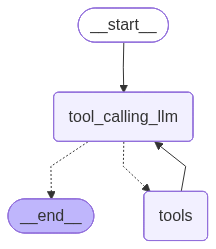

In [18]:
# state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
# define state


def tool_calling_llm(state: state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(graph)

In [19]:
response = graph.invoke({"messages": "give me recent ai news and then multiply 6 by 7"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news and then multiply 6 by 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (kq5e9pg2f)
 Call ID: kq5e9pg2f
  Args:
    query: recent ai news
    time_range: week
    topic: general
  multiply (8pn95a5hv)
 Call ID: 8pn95a5hv
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://x.com/TheRundownAI", "title": "The Rundown AI (@TheRundownAI) / Posts / X - Twitter", "content": "Top stories in AI today: - Anthropic charts path to self-improving AI - OpenAI's memory overhaul lets ChatGPT 'dream' - Stress test business ideas 4 new AI", "score": 0.65146625, "raw_content": null}], "response_time": 1.15, "request_id": "7daba377-6ca8-4654-b6a7-090a06

### Adding Memory in Agentic Graph

In [20]:
response=graph.invoke({"messages":"hello my name is a luffy?"})
for m in response["messages"]:
    m.pretty_print()

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01ksqbvd4yfhea4gcj7rxp5h9g` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 3858, Requested 2452. Please try again in 3.1s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

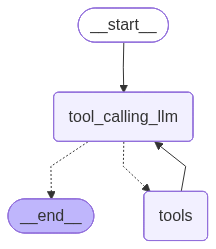

In [ ]:
# state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
# define state


def tool_calling_llm(state: state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer=memory_saver)

display(graph)

In [ ]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hello my name is luffy"},config=config)
response

{'messages': [HumanMessage(content='hello my name is luffy', additional_kwargs={}, response_metadata={}, id='56743455-a8bd-4eea-939b-178594187170'),
  AIMessage(content='Hello, Luffy! How can I assist you today? 😊', additional_kwargs={'reasoning_content': 'Okay, the user said, "hello my name is luffy." Let me think about how to respond.\n\nFirst, I need to acknowledge their greeting. A simple "Hello" seems appropriate. Then, they mentioned their name is Luffy, so I should address them by name. Maybe ask how I can assist them today. Since they didn\'t ask a specific question, keeping it friendly and open-ended makes sense. I don\'t need to use any tools here because there\'s no query or action required. Just a polite response.\n'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 1796, 'total_tokens': 1922, 'completion_time': 0.217360608, 'completion_tokens_details': {'reasoning_tokens': 107}, 'prompt_time': 0.076994437, 'prompt_tokens_details': None, 'queue

In [ ]:
response["messages"][-1].content

'Hello, Luffy! How can I assist you today? 😊'

In [ ]:
response=graph.invoke({"messages":"hey what was my name?"}, config=config)
response["messages"][-1].content

'Your name is Luffy! You mentioned it earlier. 😊 How can I help you today, Luffy?'

### Streaming

In [39]:
from langgraph.checkpoint.memory import MemorySaver
memory_saver = MemorySaver()

In [40]:
def superbot(state:state):
    return {"messages": [llm.invoke(state["messages"])]}

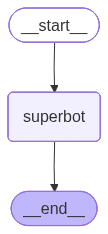

In [41]:
graph_builder = StateGraph(state)
graph_builder.add_node("superbot",superbot)
graph_builder.add_edge(START,"superbot")
graph_builder.add_edge("superbot",END)
graph=graph_builder.compile(checkpointer=memory_saver)

display(graph)

In [42]:
config={"configurable":{"thread_id":"1"}}
graph.invoke({"messages":"hello my name is luffy and i am a pirate"},config=config)

{'messages': [HumanMessage(content='hello my name is luffy and i am a pirate', additional_kwargs={}, response_metadata={}, id='b9f5ca4d-3916-4875-83da-16a44c5a70e8'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Luffy, a pirate. They probably want to roleplay or discuss pirate-related topics. I should acknowledge their name and the pirate aspect. Maybe mention the One Piece universe since Luffy is the main character there. Need to ask how I can assist them, whether it's about adventures, strategies, or something else. Keep the tone friendly and adventurous. Make sure to use appropriate emojis to match the excitement of being a pirate. Also, check if they have specific questions or need help with something. Avoid making assumptions beyond their initial statement. Let them guide the conversation further.\n</think>\n\nAhoy, Captain Luffy! 🏴\u200d☠️ The name of a pirate who’ll find the ultimate treasure, One Piece! I heard your introduction. What kind of adventure 

Streaming

Methods: .stream() and astream()

 . These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

 . values : This streams the full state of the graph after each node is called.

 . updates : This streams updates to the state of the graph after each node is called.

In [51]:
config={"configurable":{"thread_id":"3"}}

for chunk in graph.stream({'messages':"Hi,My name.is .Krish .And.I like cricket"}, config, stream_mode="updates"):
    print(chunk)



{'superbot': {'messages': [AIMessage(content='<think>\nOkay, the user, Krish, keeps sending the same message: "Hi,My name.is .Krish .And.I like cricket". I need to figure out why. Maybe there\'s a technical issue, like their message isn\'t going through properly, so they\'re resending it. Or maybe they\'re testing if I\'m paying attention. Alternatively, they might have a language barrier or cognitive difference that makes them repeat messages.\n\nI should acknowledge their greeting each time but also gently encourage them to provide more information if they want to have a meaningful conversation. The previous responses were friendly but maybe not engaging enough. Let me make the next response more interactive, ask specific questions about cricket to draw out a more detailed response. Also, check if there\'s a way to address any underlying issues if they exist. Maybe they want to talk about their favorite teams or players, or how they got into cricket. Let\'s prompt them to share more 

In [57]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph.stream({'messages':"Hi,My name.is .Krish .And.I also like football"}, config, stream_mode="values"):
    print(chunk)
    #print(chunk["messages"][-1].content)

{'messages': [HumanMessage(content='Hi,My name.is .Krish .And.I like cricket', additional_kwargs={}, response_metadata={}, id='eae7ddec-712d-491a-863b-0ee8df008768'), AIMessage(content='<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. Let me start by acknowledging their name and interest. I should make sure to correct any typos, like the extra period after "name" and "is," and the space in "My name.is .Krish .And.I like cricket." But I shouldn\'t point out the typos directly; just respond naturally.\n\nSince they like cricket, maybe ask about their favorite team or player to keep the conversation engaging. Also, offer help in case they have questions. Keep the tone friendly and open. Let me check if there\'s anything else. They might be new to the platform, so being welcoming is key. Alright, draft a response that\'s warm, corrects the typos subtly, and invites further interaction.\n</think>\n\nHi Krish! 😊 Nice to meet you! Cricket is an awesome s